In [1]:
import scanpy as sc

In [24]:
adata = sc.read("/Users/seohyon/Downloads/no_integration_batch_dkd_output.h5ad") # min batch imbalance

In [25]:
adata

AnnData object with n_obs × n_vars = 39176 × 2000
    obs: 'cell_type', 'batch'
    var: 'hvg', 'hvg_score', 'feature_name', 'feature_id'
    uns: 'dataset_id', 'dataset_organism', 'knn', 'method_id', 'normalization_id'
    obsm: 'X_emb'

In [28]:
sc.pp.neighbors(adata, use_rep="X_emb")
sc.tl.umap(adata)

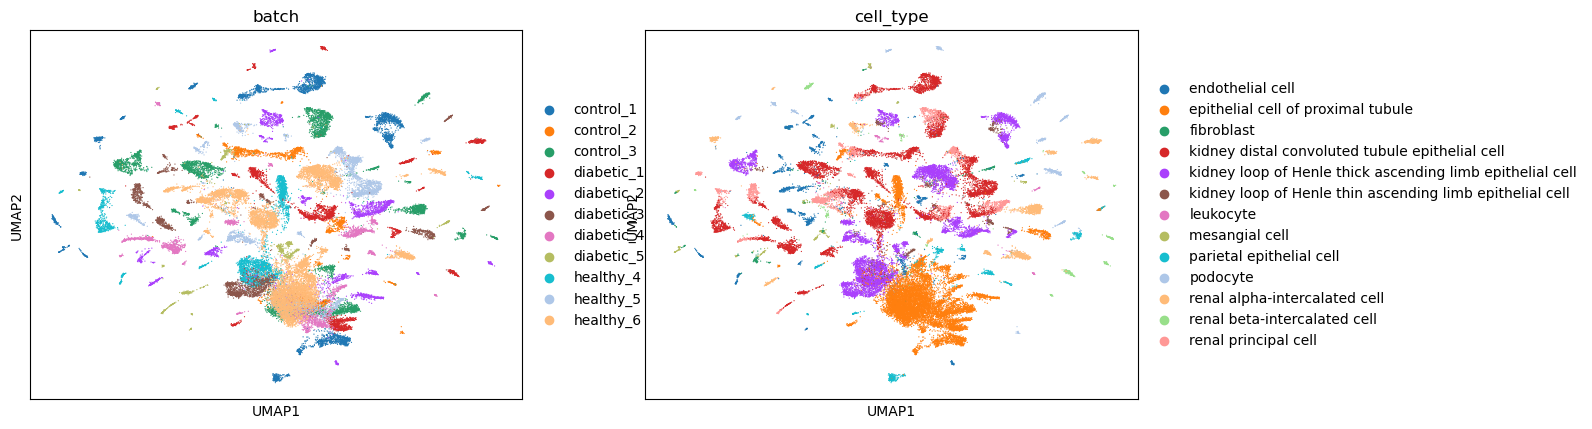

In [30]:
sc.pl.umap(adata, color=["batch", "cell_type"])

In [33]:
adata = sc.read("/Users/seohyon/Downloads/embed_cell_types_dkd_output.h5ad") # min batch imbalance

In [34]:
adata

AnnData object with n_obs × n_vars = 39176 × 0
    obs: 'cell_type', 'batch'
    uns: 'dataset_id', 'dataset_organism', 'knn', 'method_id', 'normalization_id'
    obsm: 'X_emb'

In [35]:
sc.pp.neighbors(adata, use_rep="X_emb")
sc.tl.umap(adata)

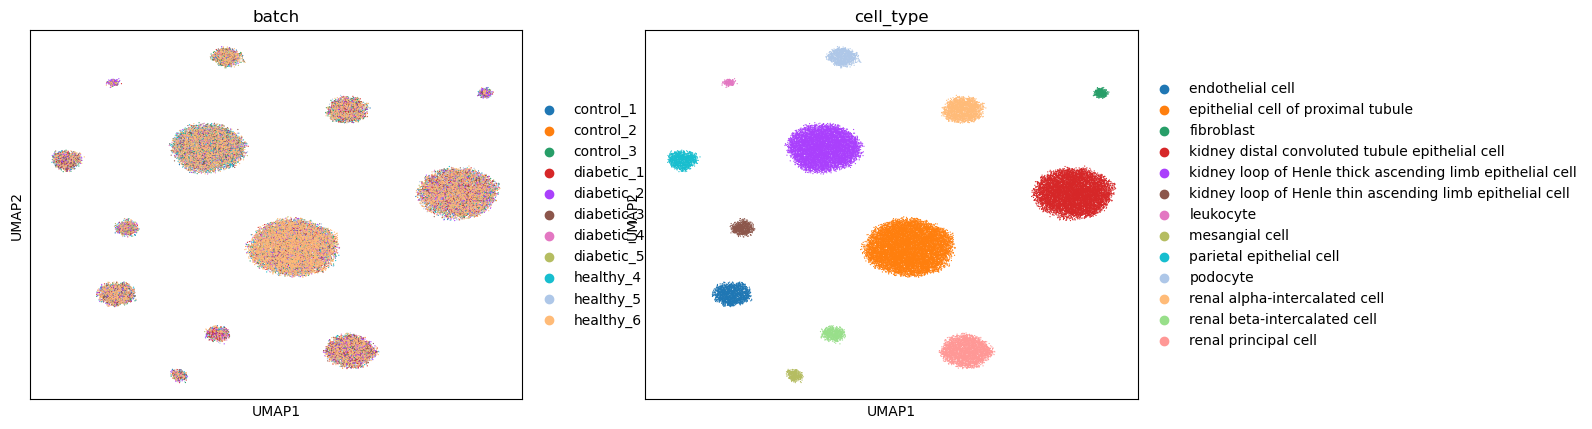

In [36]:
sc.pl.umap(adata, color=["batch", "cell_type"])

In [37]:
adata = sc.read("/Users/seohyon/Downloads/embed_cell_types_jittered_dkd_output.h5ad") # min batch imbalance

In [39]:
adata

AnnData object with n_obs × n_vars = 39176 × 0
    obs: 'cell_type', 'batch'
    uns: 'dataset_id', 'dataset_organism', 'knn', 'method_id', 'normalization_id'
    obsm: 'X_emb'

In [40]:
sc.pp.neighbors(adata, use_rep="X_emb")
sc.tl.umap(adata)

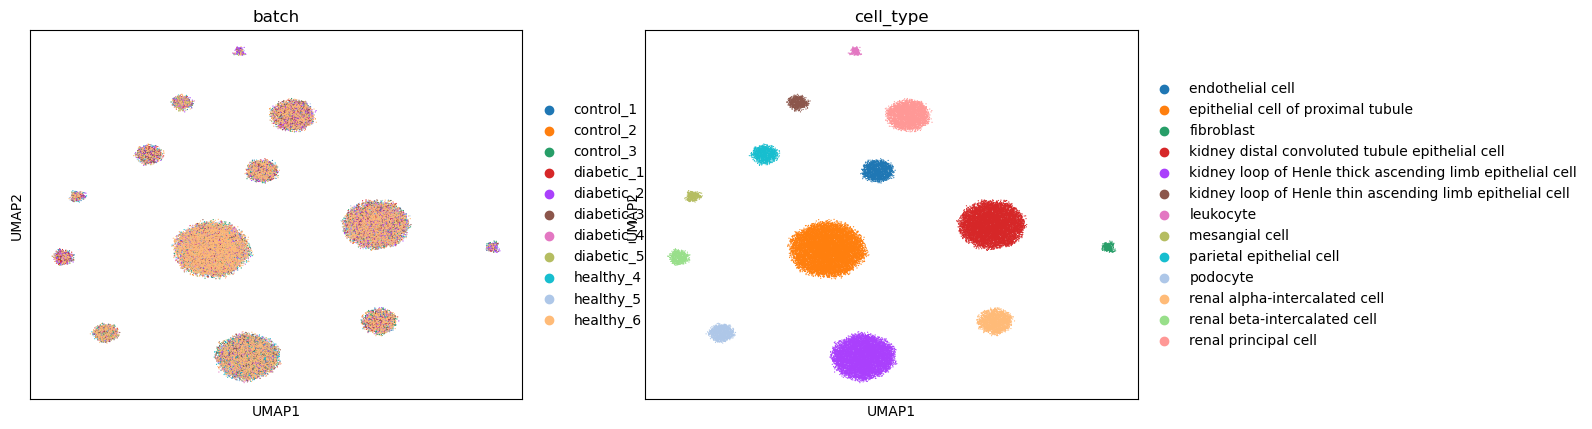

In [41]:
sc.pl.umap(adata, color=["batch", "cell_type"])

# join with barcode

In [55]:
# 1) Control / census / raw dataset with metadata
adata_meta = sc.read("/Volumes/Extreme SSD/output_agitated_brown/embed_cell_types_dkd_output.h5ad")  # or your census-based h5ad

# 2) scVI integration output (no obs, only X_emb)
adata_scvi = sc.read("/Volumes/Extreme SSD/output_agitated_brown/scvi_dkd_output.h5ad")  # the one with obsm["X_emb"]
print(adata_meta)
print(adata_scvi)

AnnData object with n_obs × n_vars = 39176 × 0
    obs: 'cell_type', 'batch'
    uns: 'dataset_id', 'dataset_organism', 'knn', 'method_id', 'normalization_id'
    obsm: 'X_emb'
AnnData object with n_obs × n_vars = 39176 × 2000
    uns: 'dataset_id', 'method_id', 'normalization_id'
    obsm: 'X_emb'


In [56]:
common = adata_meta.obs_names.intersection(adata_scvi.obs_names)
print(len(common), "cells in common")

# Subset both to the shared cells
adata_meta = adata_meta[common].copy()
adata_scvi = adata_scvi[common].copy()

# Optional: enforce the same order (good practice)
adata_meta = adata_meta[adata_scvi.obs_names].copy()

39176 cells in common


In [57]:
adata_meta.obsm["X_scvi"] = adata_scvi.obsm["X_emb"]

In [58]:
sc.pp.neighbors(adata_meta, use_rep="X_scvi", n_neighbors=15, n_pcs=None)
sc.tl.umap(adata_meta)

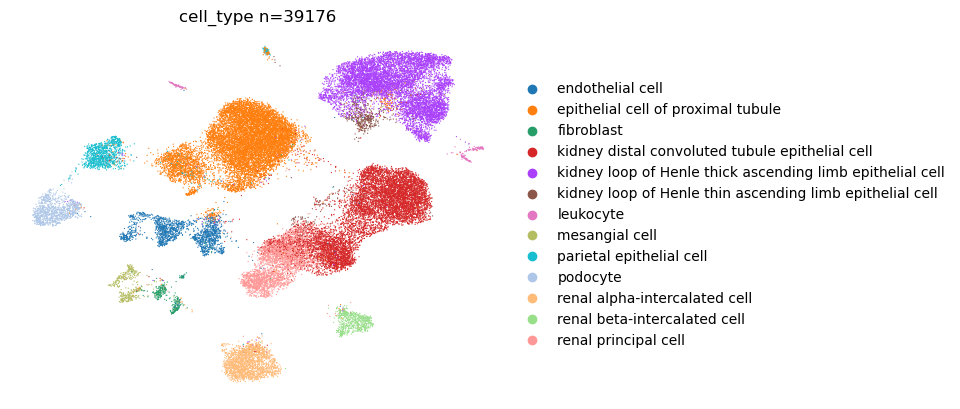

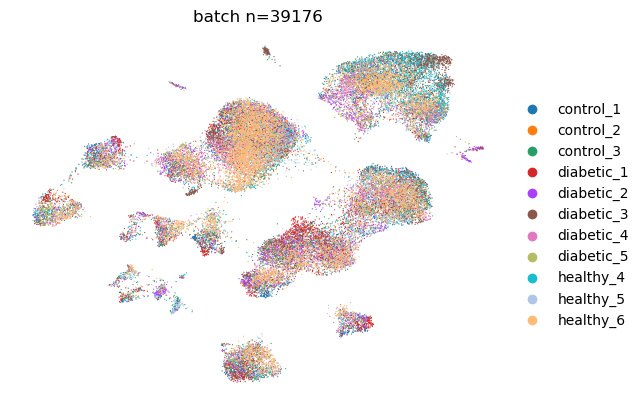

In [59]:
for color in ['cell_type', 'batch']:
    sc.pl.embedding(
        adata_meta,
        basis='X_umap',           # NOT use_rep
        color=color,              # singular "color"
        title=f'{color} n={adata_meta.n_obs}',
        frameon=False,
    )


In [47]:
# 1) Control / census / raw dataset with metadata
adata_meta = sc.read("/Volumes/Extreme SSD/output_agitated_brown/embed_cell_types_jittered_hypomap_output.h5ad")  # or your census-based h5ad

# 2) scVI integration output (no obs, only X_emb)
adata_scvi = sc.read("/Volumes/Extreme SSD/output_agitated_brown/scvi_hypomap_output.h5ad")  # the one with obsm["X_emb"]
print(adata_meta)
print(adata_scvi)

AnnData object with n_obs × n_vars = 384925 × 0
    obs: 'cell_type', 'batch'
    uns: 'dataset_id', 'dataset_organism', 'knn', 'method_id', 'normalization_id'
    obsm: 'X_emb'
AnnData object with n_obs × n_vars = 384925 × 2000
    uns: 'dataset_id', 'method_id', 'normalization_id'
    obsm: 'X_emb'


In [48]:
adata_meta.obsm["X_scvi"] = adata_scvi.obsm["X_emb"]

In [49]:
sc.pp.neighbors(adata_meta, use_rep="X_scvi", n_neighbors=15, n_pcs=None)
sc.tl.umap(adata_meta)

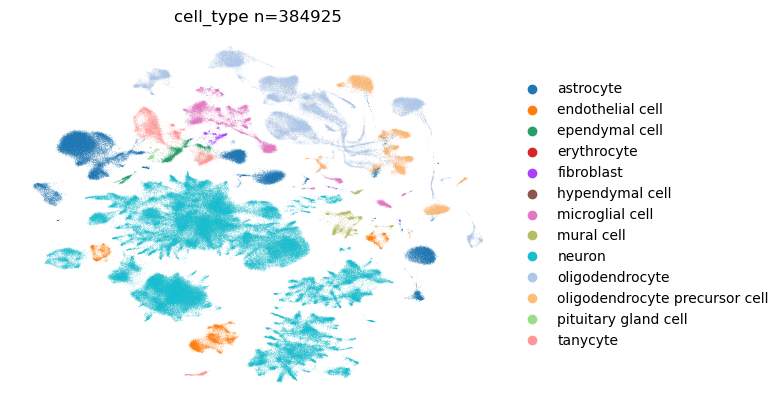

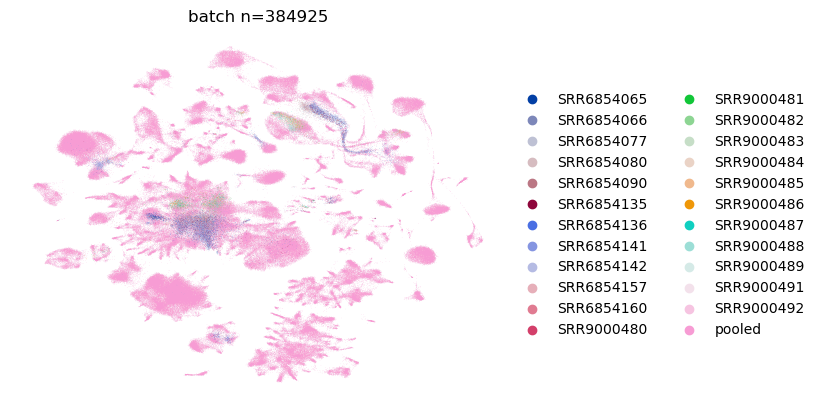

In [53]:
for color in ['cell_type', 'batch']:
    sc.pl.embedding(
        adata_meta,
        basis='X_umap',
        color=color,
        title=f'{color} n={adata_meta.n_obs}',
        frameon=False,
    )
